# My name is ozymandias, King of kings, Look upon my works ye mighty and despair

# Behold the Optical Pumping

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

In [122]:
# Converting the sweep values to b field values:
def add_magnetic_field(filename, timeconst):
    ItB = (0.6*10e-4)#Teslas
    df = pd.read_csv(filename, skiprows=2, usecols=[0, 1, 2], names=["Sequence", "CH1", "CH2"])
    df["Bfield"] = (df["CH1"]*ItB)/10
    df["CH2norm"] = (df["CH2"] - min(df["CH2"]))/(max(df["CH2"])-min(df["CH2"]))
    df["time"] = df["Sequence"]*timeconst
    filename, ext = os.path.splitext(filename)
    new_filename = f"{filename}_B{ext}"
    df.to_csv(new_filename, index=False)
    print("New file:",new_filename) 
    return df

df_25 = add_magnetic_field("linear_zeeman_data/NewFile25kHz.csv",5.000000e-03)
df_50 = add_magnetic_field("linear_zeeman_data/NewFile50kHz.csv",5.000000e-03)
df_75 = add_magnetic_field("linear_zeeman_data/NewFile75kHz.csv",5.000000e-03)
df_100 = add_magnetic_field("linear_zeeman_data/NewFile100kHz.csv",5.000000e-03)
df_125 = add_magnetic_field("linear_zeeman_data/NewFile125kHz.csv",5.000000e-03)
df_150 = add_magnetic_field("linear_zeeman_data/NewFile150kHz.csv",5.000000e-03)
df_175 = add_magnetic_field("linear_zeeman_data/NewFile175kHz.csv",5.000000e-03)
df_195 = add_magnetic_field("linear_zeeman_data/NewFile195kHz.csv",5.000000e-03)

New file: linear_zeeman_data/NewFile25kHz_B.csv
New file: linear_zeeman_data/NewFile50kHz_B.csv
New file: linear_zeeman_data/NewFile75kHz_B.csv
New file: linear_zeeman_data/NewFile100kHz_B.csv
New file: linear_zeeman_data/NewFile125kHz_B.csv
New file: linear_zeeman_data/NewFile150kHz_B.csv
New file: linear_zeeman_data/NewFile175kHz_B.csv
New file: linear_zeeman_data/NewFile195kHz_B.csv


### Lorentzian fit of the data:

$$f(x;A,x_0,\gamma) = A\cdot\frac{\gamma^2}{\gamma^2+(x-x_0)^2}$$

Specific heat capacity is analogous to your trainability coefficient. You want the specific heat capacity to be as low as possible for quick change of temperature in solids, similarly you want high trainability for weights. inversely related.

$$T_b \propto \frac{1}{C}$$


Solomonoff induction is actually stupid as fuck bruah. it's just an induction process that takes you from arbitrarily deciding the truth/ or arbitrary delibartion of the truth of any matter to something more justifiable and realistic. Solomonoff induction is basically bayesian statistics, coupled with hypothesis testing (perhaps a close link to the scientific method).  

In [123]:
def lorentzian(x,ampl,center,hwhm,y0):
    return y0+(ampl*((hwhm**2)/(hwhm**2+(x-center)**2)))

In [124]:
def triple_lorentzian(x, y0, a1, c1, w1, a2, c2, w2, a3, c3, w3):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    L3 = a3 / (1 + ((x - c3) / w3)**2)
    return y0 + L1 + L2 + L3

In [125]:
def fit_lorentzian(p0,df):
    x_data,y_data = df["time"],df["CH2norm"]
    popt, pcov = curve_fit(triple_lorentzian,x_data,y_data,p0=p0)
    perr = np.sqrt(np.diag(pcov))
    print(f"Lorentzian peak 1:{popt[2]}±{perr[2]}")
    print(f"Lorentzian peak 2:{popt[5]}±{perr[5]}")
    print(f"Lorentzian peak 3:{popt[8]}±{perr[8]}")
    plt.plot(x_data, y_data, label='Data')
    plt.scatter(p0[2],p0[1])
    plt.scatter(p0[5],p0[4])
    plt.scatter(p0[8],p0[7])
    plt.plot(x_data, triple_lorentzian(x_data, *popt), 'r-', label='Fitted Lorentzian')
    plt.legend()
    plt.show()
    return popt,perr

In [ ]:
p0_guesses = [[1.0,0,2.025,0.018,0.2,2.5,0.023,0.6,2.3,0.022],
              [1.0,0,2.025,0.018,0.2,3.2,0.023,0.6,2.8,0.022],
              [1.0,0,2.025,0.018,0.2,3.5,0.023,0.5,3.1,0.022],
              ,
              ]

Lorentzian peak 1:2.029705351462113±0.0005712702166012949
Lorentzian peak 2:2.5016470058534837±0.0007230646340538515
Lorentzian peak 3:2.3443990707326954±0.0013892150540064567


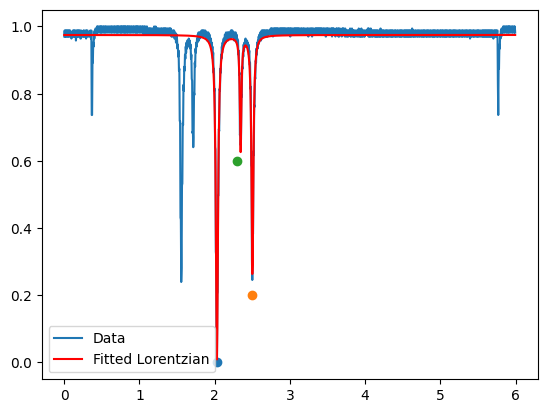

In [ ]:
p0_guess = [1.0,0,2.025,0.018,0.2,2.5,0.023,0.6,2.3,0.022]
popt,perr = fit_lorentzian(p0_guess,df_25)

Lorentzian peak 1:2.18078880862279±0.001174237712530607
Lorentzian peak 2:3.123095104849237±0.0009597199217436241
Lorentzian peak 3:2.8084798351956595±0.0019079319370380998


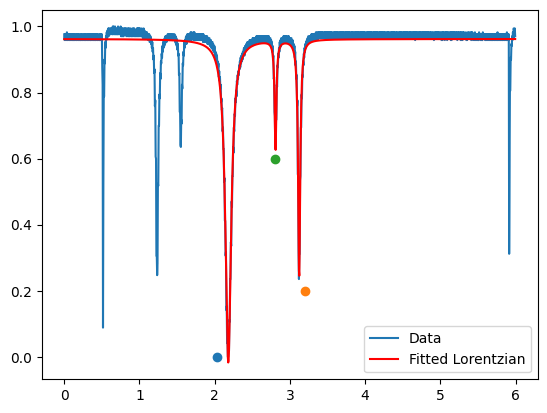

In [127]:
p0_guess = [1.0,0,2.025,0.018,0.2,3.2,0.023,0.6,2.8,0.022]
popt,perr = fit_lorentzian(p0_guess,df_50)

Lorentzian peak 1:2.1668639113512884±0.0014982551023510567
Lorentzian peak 2:3.582734137370189±0.001087551501662
Lorentzian peak 3:3.109609303261243±0.002181529383978733


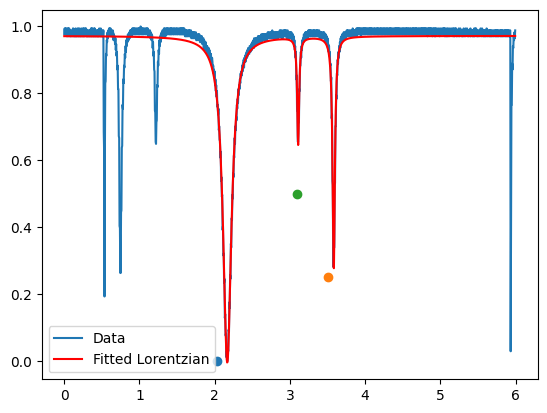

In [128]:
p0_guess = [1.0,0,2.025,0.018,0.25,3.5,0.023,0.5,3.1,0.022]
popt,perr = fit_lorentzian(p0_guess,df_75)

Lorentzian peak 1:2.1745823809406493±0.0011430155258152842
Lorentzian peak 2:4.063414275830429±0.0009537770626800475
Lorentzian peak 3:3.4342450116601144±0.0018747980826242289


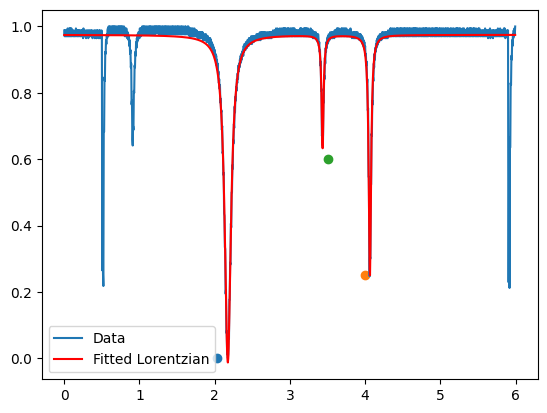

In [129]:
p0_guess = [1.0,0.0,2.025,0.018,0.25,4,0.023,0.6,3.5,0.022]
popt,perr = fit_lorentzian(p0_guess,df_100)

Lorentzian peak 1:2.160954190650837±0.0014410392997696382
Lorentzian peak 2:4.522293924165618±0.0010780696181609123
Lorentzian peak 3:3.7355842665348065±0.002122405556460715


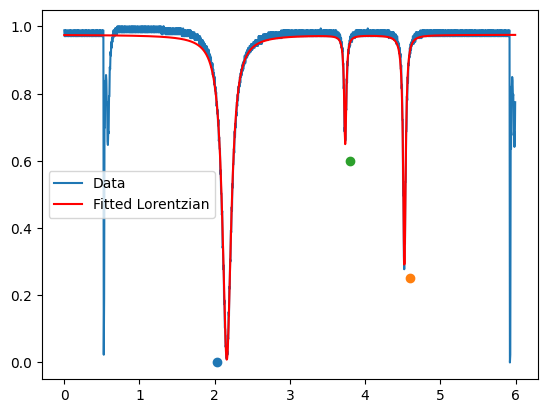

In [130]:
p0_guess = [1.0,0.0,2.025,0.018,0.25,4.6,0.023,0.6,3.8,0.022]
popt,perr = fit_lorentzian(p0_guess,df_125)

Lorentzian peak 1:2.17765268976929±0.0008101733568726876
Lorentzian peak 2:5.012642738592269±0.0007167642094359707
Lorentzian peak 3:4.0688179820553625±0.001448969469501177


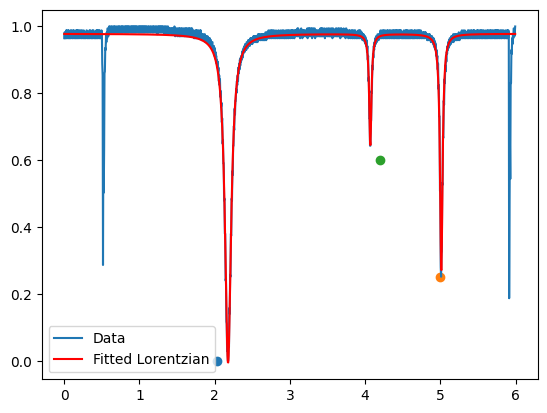

In [131]:
p0_guess = [1.0,0.0,2.025,0.018,0.25,5,0.023,0.6,4.2,0.022]
popt,perr = fit_lorentzian(p0_guess,df_150)

Lorentzian peak 1:2.1725604799149094±0.000954082342986324
Lorentzian peak 2:5.47934656398605±0.001019054346948234
Lorentzian peak 3:4.378771863206601±0.002017082276075628


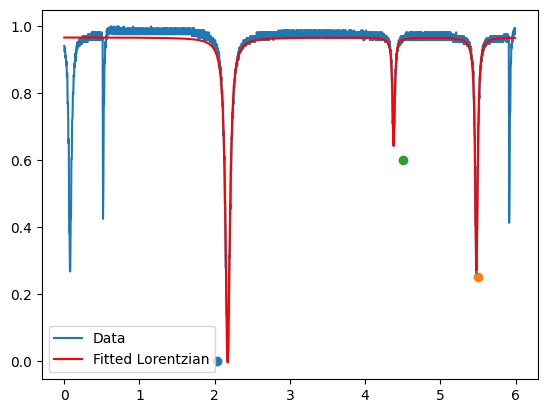

In [132]:
p0_guess = [1.0,0.0,2.025,0.018,0.25,5.5,0.023,0.6,4.5,0.022]
popt,perr = fit_lorentzian(p0_guess,df_175)

Lorentzian peak 1:2.0287108660237188±0.000587734066416981
Lorentzian peak 2:5.712892101184858±0.0008795870155278204
Lorentzian peak 3:4.488497596252746±0.0017850654128319316


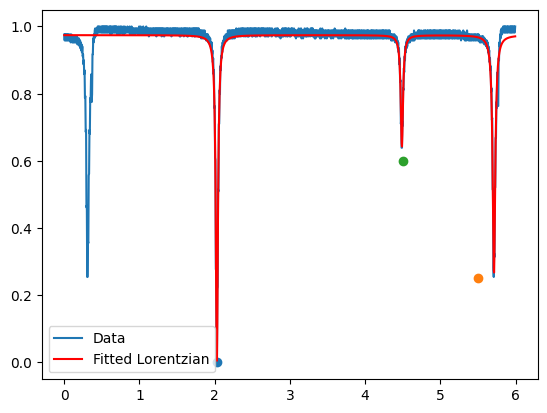

In [133]:
p0_guess = [1.0,0.0,2.025,0.018,0.25,5.5,0.023,0.6,4.5,0.022]
popt,perr = fit_lorentzian(p0_guess,df_195)